# 01. Análise Exploratória da Série Temporal

**Objetivo:** Desenvolver um modelo de séries temporais capaz de prever o preço de fechamento (`Close`) de uma ação na bolsa, utilizando como base o histórico de preços disponíveis.


In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import utils as ut

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#444444", "axes.grid": True,
    "grid.color": "#e5e5e5", "grid.linewidth": 0.8, "font.size": 11,
})
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 1. Carregar os dados brutos e checar qualidade

In [2]:
train_raw, test_raw = cu.load_raw("../data/raw")

print(f"Treino (raw): {len(train_raw)} linhas | {train_raw['Date'].min().date()} a {train_raw['Date'].max().date()}")
print(f"Teste  (raw): {len(test_raw)} linhas | {test_raw['Date'].min().date()} a {test_raw['Date'].max().date()}")

overlap = set(train_raw["Date"]).intersection(set(test_raw["Date"]))
print(f"\nDatas duplicadas no treino: {train_raw['Date'].duplicated().sum()}")
print(f"Datas duplicadas no teste:  {test_raw['Date'].duplicated().sum()}")
print(f"Datas sobrepostas entre treino e teste: {len(overlap)}  (tem que ser 0)")


Treino (raw): 1345 linhas | 2013-01-02 a 2018-05-25
Teste  (raw): 19 linhas | 2018-05-28 a 2018-06-22

Datas duplicadas no treino: 0
Datas duplicadas no teste:  0
Datas sobrepostas entre treino e teste: 0  (tem que ser 0)


In [3]:
missing = train_raw.isna().sum()
print("Valores ausentes por coluna (treino, raw):")
print(missing[missing > 0] if missing.sum() else "Nenhum ausente isolado, mas veja as linhas 100% vazias abaixo:")

linhas_vazias = train_raw[train_raw["Close"].isna()]
print("\nLinhas totalmente vazias:")
linhas_vazias


Valores ausentes por coluna (treino, raw):
Open         3
High         3
Low          3
Close        3
Adj Close    3
Volume       3
dtype: int64

Linhas totalmente vazias:


,Date,Open,High,Low,Close,Adj Close,Volume
58,2013-03-28,NaN,NaN,NaN,NaN,NaN,NaN
78,2013-04-26,NaN,NaN,NaN,NaN,NaN,NaN
140,2013-07-26,NaN,NaN,NaN,NaN,NaN,NaN


Três datas de pregão (28/03/2013, 26/04/2013, 26/07/2013) vieram com todas as colunas em branco. São apenas 3 em 1.345 linhas (0,2%), então esses valores são interpolados linearmente a partir dos dias adjacentes.

## 2. Limpar e salvar

In [4]:
train, test = cu.clean_and_save(train_raw, test_raw, "../data/processed")
assert train["Close"].isna().sum() == 0
print("Dados limpos e salvos em data/processed/. Shapes:", train.shape, test.shape)


Dados limpos e salvos em data/processed/. Shapes: (1345, 7) (19, 7)


In [5]:
full = cu.make_full_series(train, test)

full_bdays = pd.bdate_range(train["Date"].min(), train["Date"].max())
missing_bdays = full_bdays.difference(train["Date"])
diffs = train["Date"].diff().dt.days.dropna()

print(f"Frequência: diária, apenas em dias úteis (padrão de bolsa).")
print(f"Dias úteis esperados no período de treino: {len(full_bdays)}")
print(f"Dias úteis ausentes (feriados de bolsa): {len(missing_bdays)}")
print(f"Maior buraco entre pregões consecutivos: {int(diffs.max())} dias corridos")


Frequência: diária, apenas em dias úteis (padrão de bolsa).
Dias úteis esperados no período de treino: 1408
Dias úteis ausentes (feriados de bolsa): 63
Maior buraco entre pregões consecutivos: 5 dias corridos


Conclusão da checagem de qualidade: a série é diária em dias úteis, sem duplicidade, sem sobreposição treino/teste, com apenas 3 linhas interpoladas. Os "buracos" de calendário são feriados de bolsa normais, nada que indique erro de coleta.

### Outliers e choques de preço

In [6]:
def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return s[(s < lo) | (s > hi)]

print("Outliers de Close (IQR):", len(iqr_outliers(train["Close"])))
print("Outliers de Volume (IQR):", len(iqr_outliers(train["Volume"])), "(picos de volume em dias de notícia, normal, não é erro)")

retorno = train["Close"].pct_change()
choques = train[retorno.abs() > 4 * retorno.std()][["Date", "Close"]].assign(retorno=retorno[retorno.abs() > 4 * retorno.std()])
print("\nMaiores choques de retorno diário (acima de 4 desvios-padrão):")
choques


Outliers de Close (IQR): 1
Outliers de Volume (IQR): 41 (picos de volume em dias de notícia, normal, não é erro)

Maiores choques de retorno diário (acima de 4 desvios-padrão):


,Date,Close,retorno
518,2015-02-03,9.9700,0.1342
774,2016-02-22,5.0400,0.1300
782,2016-03-03,6.5700,0.1628
1083,2017-05-18,13.1500,-0.1576
1343,2018-05-24,20.0800,-0.1371


Destaque para a queda de -13,7% em 24/05/2018, um dia útil antes do início do período de teste. Isso não é erro de dado, é um evento real de mercado, e será importante para interpretar o desempenho dos modelos: qualquer previsão feita a partir do fim do treino já "nasce" sabendo desse choque (ele está no último valor observado), mas nenhum modelo poderia tê-lo antecipado.

## 3. Plotar a série (alvo: `Close`)

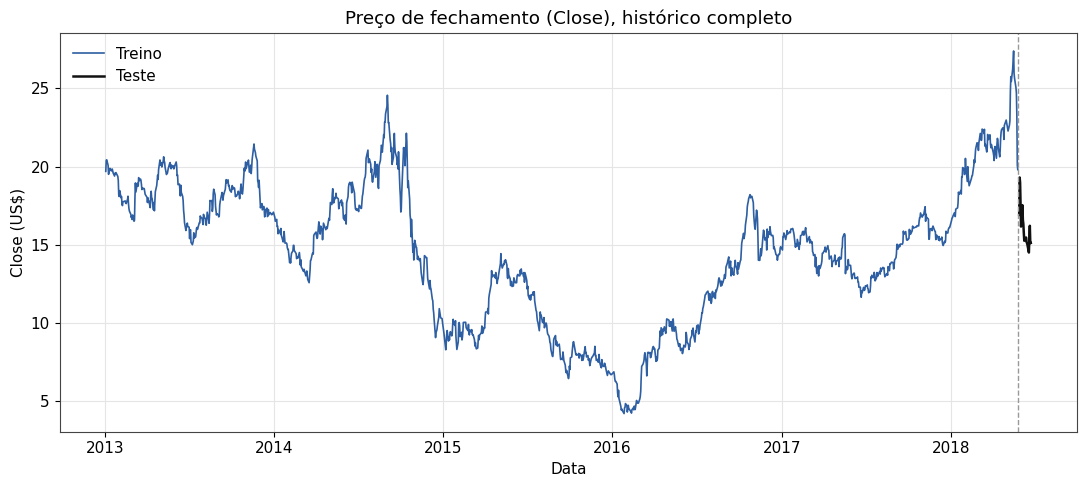

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(train["Date"], train["Close"], color=cu.PALETTE["treino"], linewidth=1.2, label="Treino")
ax.plot(test["Date"], test["Close"], color=cu.PALETTE["real"], linewidth=1.8, label="Teste")
ax.axvline(train["Date"].max(), color="#999999", linestyle="--", linewidth=1)
ax.set_title("Preço de fechamento (Close), histórico completo")
ax.set_xlabel("Data"); ax.set_ylabel("Close (US$)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


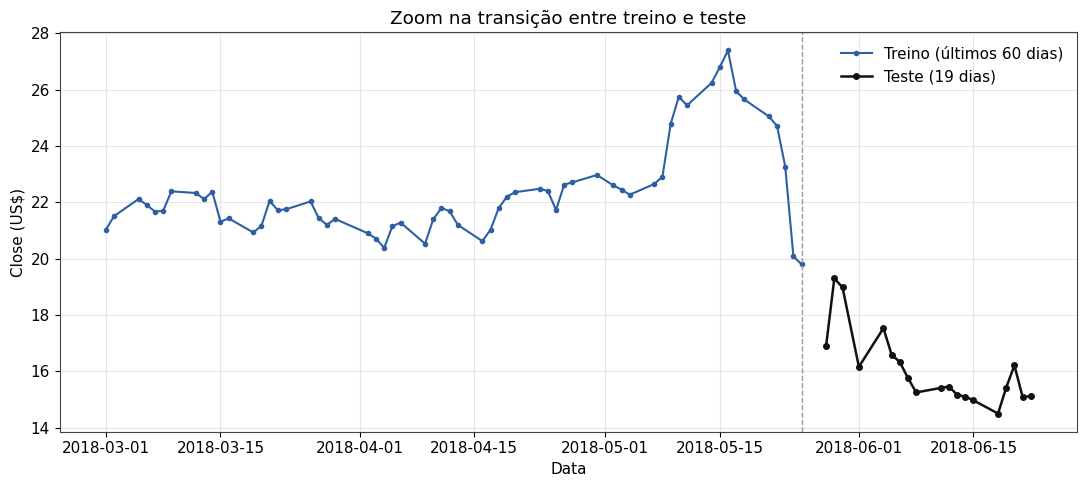

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(train["Date"].tail(60), train["Close"].tail(60), color=cu.PALETTE["treino"], linewidth=1.5, marker="o", markersize=3, label="Treino (últimos 60 dias)")
ax.plot(test["Date"], test["Close"], color=cu.PALETTE["real"], linewidth=1.8, marker="o", markersize=4, label="Teste (19 dias)")
ax.axvline(train["Date"].max(), color="#999999", linestyle="--", linewidth=1)
ax.set_title("Zoom na transição entre treino e teste")
ax.set_xlabel("Data"); ax.set_ylabel("Close (US$)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 4. Tendência e sazonalidade

/tmp/ipykernel_773/382016740.py:2: FutureWarning: `extrapolate_trend='freq'` is deprecated and will be removed in 0.16, use `extrapolate_trend='period'` instead.
  decomp = seasonal_decompose(s, model="additive", period=5, extrapolate_trend="freq")


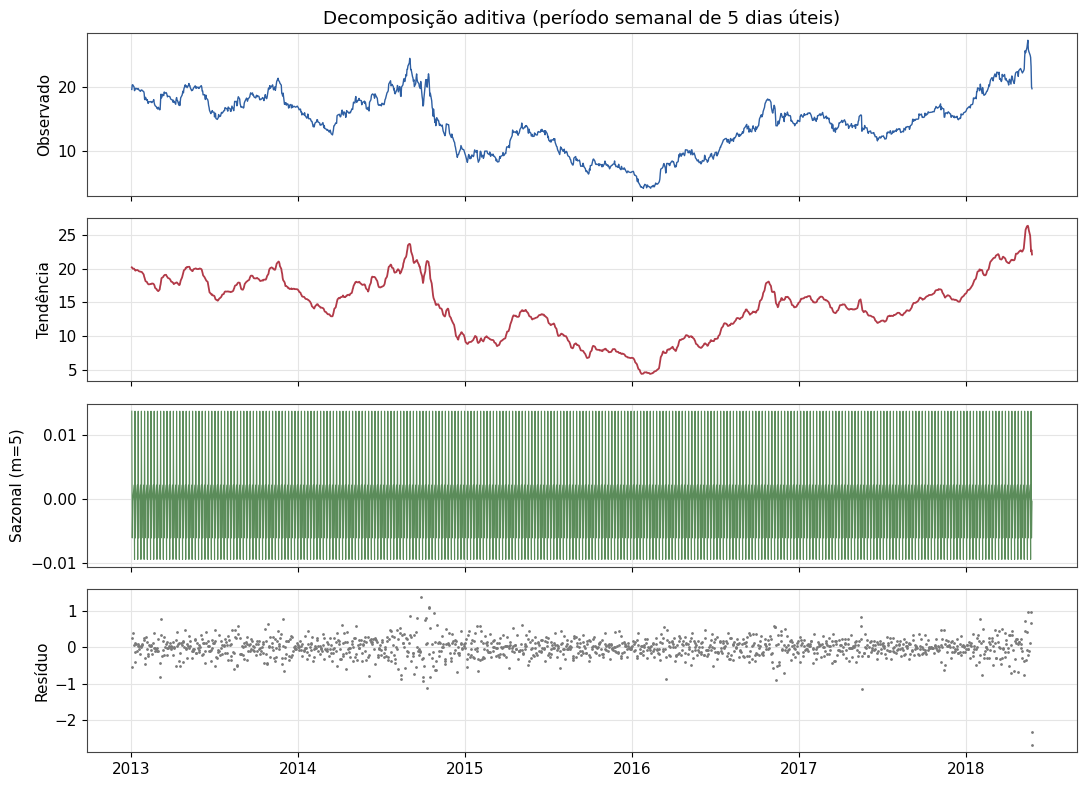

Amplitude da sazonalidade: 0.0231   Amplitude da tendência: 22.04
A sazonalidade semanal representa 0.105% da amplitude da tendência, ou seja, é irrelevante.


In [9]:
s = train.set_index("Date")["Close"].asfreq("B").interpolate(limit_direction="both")
decomp = seasonal_decompose(s, model="additive", period=5, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
axes[0].plot(decomp.observed, color=cu.PALETTE["treino"], linewidth=1); axes[0].set_ylabel("Observado")
axes[1].plot(decomp.trend, color="#B23A48", linewidth=1.3); axes[1].set_ylabel("Tendência")
axes[2].plot(decomp.seasonal, color="#5B8C5A", linewidth=0.8); axes[2].set_ylabel("Sazonal (m=5)")
axes[3].plot(decomp.resid, color="#7A7A7A", linewidth=0.8, marker=".", markersize=2, linestyle="none"); axes[3].set_ylabel("Resíduo")
axes[0].set_title("Decomposição aditiva (período semanal de 5 dias úteis)")
fig.tight_layout()
plt.show()

amp_sazonal = decomp.seasonal.max() - decomp.seasonal.min()
amp_tendencia = decomp.trend.max() - decomp.trend.min()
print(f"Amplitude da sazonalidade: {amp_sazonal:.4f}   Amplitude da tendência: {amp_tendencia:.2f}")
print(f"A sazonalidade semanal representa {amp_sazonal/amp_tendencia*100:.3f}% da amplitude da tendência, ou seja, é irrelevante.")


Conclusão: a tendência de longo prazo domina a série; a sazonalidade semanal é praticamente inexistente, o que é consistente com a hipótese de mercados eficientes: não há "dia da semana" que puxe o preço sistematicamente.

## 5. Estacionariedade, ACF e PACF

A estrutura de autocorrelação que os modelos AR/ARMA/ARIMA (notebook 02) exploram é analisada a seguir.

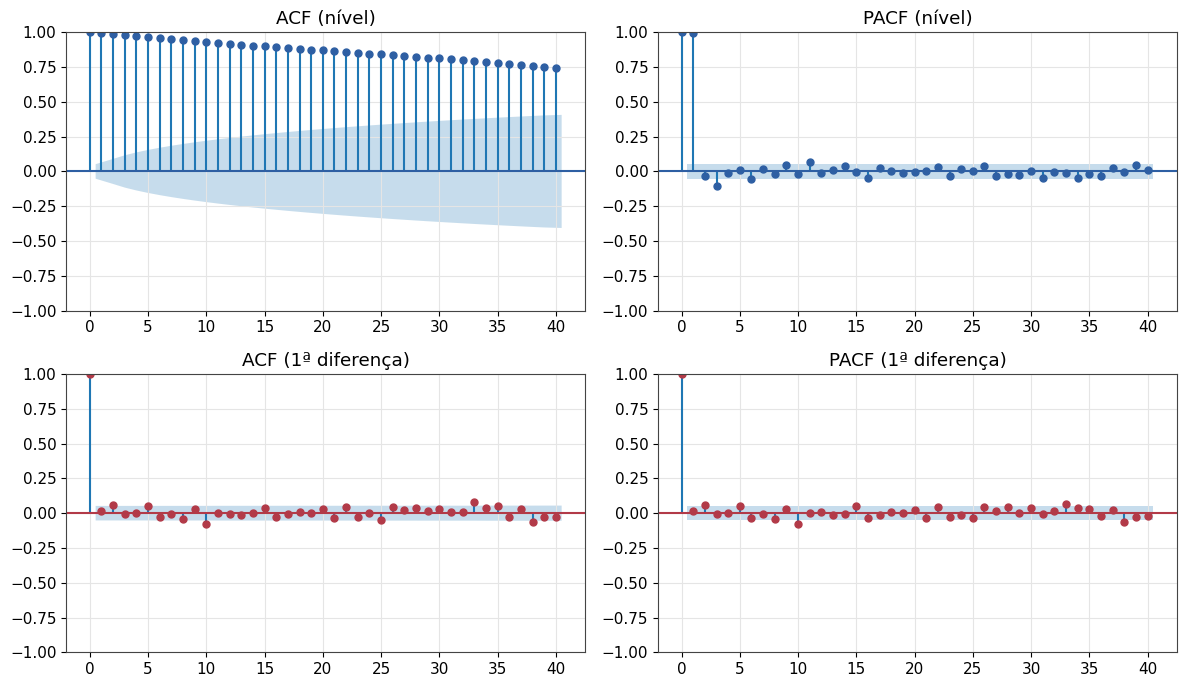

In [10]:
close_level = s
close_diff = s.diff().dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
plot_acf(close_level, lags=40, ax=axes[0, 0], color=cu.PALETTE["treino"]); axes[0, 0].set_title("ACF (nível)")
plot_pacf(close_level, lags=40, ax=axes[0, 1], color=cu.PALETTE["treino"], method="ywm"); axes[0, 1].set_title("PACF (nível)")
plot_acf(close_diff, lags=40, ax=axes[1, 0], color="#B23A48"); axes[1, 0].set_title("ACF (1ª diferença)")
plot_pacf(close_diff, lags=40, ax=axes[1, 1], color="#B23A48", method="ywm"); axes[1, 1].set_title("PACF (1ª diferença)")
fig.tight_layout()
plt.show()


In [11]:
adf_level = adfuller(close_level)
adf_diff = adfuller(close_diff)
print(f"ADF nível:      estatística={adf_level[0]:.4f}  p-valor={adf_level[1]:.4f}")
print(f"ADF diferença:  estatística={adf_diff[0]:.4f}  p-valor={adf_diff[1]:.4f}")


ADF nível:      estatística=-1.7633  p-valor=0.3988
ADF diferença:  estatística=-11.9820  p-valor=0.0000


/tmp/ipykernel_773/1808127702.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_level = adfuller(close_level)
/tmp/ipykernel_773/1808127702.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_diff = adfuller(close_diff)


Conclusão: a ACF decaindo lentamente e a PACF cortando no lag 1, em nível, formam a assinatura clássica de passeio aleatório. O teste ADF confirma: não estacionária em nível (p-valor alto), estacionária após 1 diferenciação (p-valor < 0,001), portanto `d = 1` é usado nos modelos ARIMA. Na diferença, ACF e PACF não mostram lags significativos: os retornos diários se comportam como ruído branco, então não é esperada muita informação preditiva linear de curto prazo.

## 6. Definindo o problema multi-horizonte (h = 1, 2, 3)

O objetivo do case é prever o `Close` para 1, 2 e 3 dias úteis à frente. Ou seja, se hoje é sexta-feira, "1 dia à frente" é o próximo dia de pregão (segunda), "2 dias à frente" é terça, e assim por diante. A bolsa não funciona aos finais de semana, então os "h dias" aqui são sempre dias úteis de pregão, não dias corridos.

### Esquema de validação: walk-forward respeitando o tempo

Para comparar o erro de previsão em h=1, h=2 e h=3 de forma robusta, e não apenas com um único ponto, é usada uma validação walk-forward com janela expansiva:

1. O último dia do treino é tomado como "hoje" (origem 0) e os 3 dias seguintes do teste são previstos.
2. A origem avança um dia, o valor real do primeiro dia de teste já é conhecido, e os 3 dias seguintes são previstos novamente.
3. O processo se repete até restarem menos de 3 dias de teste para avaliar.

Isso simula exatamente o uso real: a cada novo dia de pregão, o valor real se torna conhecido e entra no histórico antes da próxima rodada de previsão. Um valor futuro nunca é usado para prever esse mesmo valor ou algo anterior a ele.

In [12]:
origins = cu.walkforward_origins(len(train), len(test), max_h=max(cu.HORIZONS))
print(f"Número de origens de validação: {len(origins)}")
print(f"Primeira origem: {full.loc[origins[0], 'Date'].date()} (prevê {[full.loc[origins[0]+h, 'Date'].date() for h in cu.HORIZONS]})")
print(f"Última origem:   {full.loc[origins[-1], 'Date'].date()} (prevê {[full.loc[origins[-1]+h, 'Date'].date() for h in cu.HORIZONS]})")


Número de origens de validação: 17
Primeira origem: 2018-05-25 (prevê [datetime.date(2018, 5, 28), datetime.date(2018, 5, 29), datetime.date(2018, 5, 30)])
Última origem:   2018-06-19 (prevê [datetime.date(2018, 6, 20), datetime.date(2018, 6, 21), datetime.date(2018, 6, 22)])


Com 19 dias de teste e horizonte máximo de 3, há 17 origens de validação, ou seja, 17 previsões de h=1, 17 de h=2 e 17 de h=3 para calcular métricas robustas (MAE, RMSE, MAPE) por horizonte, em vez de um único ponto.

Os próximos notebooks (`02_baseline_modelos_classicos` e `03_machine_learning`) implementam essa validação para cada família de modelo, e o `04_comparacao_final` consolida os resultados.